# ex-8 two-factor — the complete $(b_1, b_2)$ disk

The two-factor model ported into this repo as its own notebook (working copy for new
work). At $k=2$ the population subspace is a single plane, so one disk shows
**everything**: each replicate's estimate $h_j$ is the plain coordinate pair
$(\langle b_1,h_j\rangle, \langle b_2,h_j\rangle)$ — radius is exactly
$\sqrt{1-\lVert\Pi^{\perp}h_j\rVert^2}$ and the tilt off its own axis is the
1$\leftrightarrow$2 leakage. Nothing is hidden in a third coordinate.

Sweeps load from `nb_outputs/ex8_df_{p,n}.parquet` (regenerated here if missing or if the
model/design fingerprint changed — the `.spec.json` sidecar guards against stale caches).
The growing-p cache is the same one behind `ex-9_two_factor_data`, so the replicates match.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import grid, Row, BoxDist, RefOverlay, DiskDensity, THEME

DATA_DIR = REPO_ROOT / "nb_outputs"
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR = DATA_DIR / "ex8_two_factor"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


K = 2
model = ModelSpec(
    k_factors=K,
    factor_vols=[0.16, 0.08],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"

# True limiting Gram from the sampler moments: E[β_i β_j] = loc_i·loc_j + δ_ij·scale_i²
# (independence only kills the noise cross-terms; nonzero locs correlate the rows).
_locs = np.array([s.get("loc", 0.0) for s in model.beta_samplers])
_scales = np.array([s.get("scale", 1.0) for s in model.beta_samplers])
G_limit = np.outer(_locs, _locs) + np.diag(_scales ** 2)
K_limit = np.diag(model.factor_vols) @ G_limit @ np.diag(model.factor_vols)
spikes = np.sort(np.linalg.eigvalsh(K_limit))[::-1]     # true population spikes
print("limiting Gram G:\n", np.round(G_limit, 4))
print("true spikes (eigs of diag(σ)·G·diag(σ)):", np.round(spikes, 5),
      " ratio:", round(spikes[0] / spikes[1], 2))
print("predicted floors at n=63:", np.round(0.16 / (63 * spikes + 0.16), 4))

limiting Gram G:
 [[1.25 0.  ]
 [0.   1.  ]]
true spikes (eigs of diag(σ)·G·diag(σ)): [0.032  0.0064]  ratio: 5.0
predicted floors at n=63: [0.0735 0.2841]


## Steps 1–2 — record + sweeps

In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k×k realized Gram."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k, n = context.k, context.T
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        c_half = np.sqrt((context.model.B ** 2).mean(axis=1))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        result["nu_coords"] = vecs[:, np.argsort(vals)[::-1]]
        return result


class ProjectedSpectrumAnalysis:
    """Dual-Gram PCA with the finite-p split AND the raw projection coordinates."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        sin2_angle, _ = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)
        coeffs = self.population_loading_directions_b_pop @ H
        in_subspace = (coeffs ** 2).sum(axis=0)
        return {"sin2_j": sin2_angle,
                "measured_out_of_subspace": 1.0 - in_subspace,
                "h_coords": coeffs}


class InSubRotationExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ProjectedSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        C, W = merged["h_coords"], merged["nu_coords"]
        return [{
            "n": n, "p": p, "j": j + 1,
            "sin2_j": float(merged["sin2_j"][j]),
            "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
            "rotation": float(merged["rotation"][j]),
            "measured_out_of_subspace": float(merged["measured_out_of_subspace"][j]),
            **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
            **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
        } for j in range(k)]


design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 63, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

_REQ = {f"hb{i}" for i in range(1, K + 1)} | {f"nu{i}" for i in range(1, K + 1)}
import json as _json


def _spec_fingerprint(design):
    # Everything that determines the sweep's numbers — model AND design. A cached
    # parquet is valid only if its sidecar fingerprint matches exactly, so editing
    # vols/locs/reps can never silently serve stale data again.
    return _json.dumps({
        "k": model.k_factors, "vols": list(model.factor_vols),
        "betas": model.beta_samplers, "idio": model.idio_vol_sampler,
        "n": list(design.n_values), "p": list(design.p_values),
        "reps": design.n_reps, "seed": design.random_seed,
        "tails": HEAVY_TAIL}, sort_keys=True)


def load_or_run(path, design, label):
    spec = _spec_fingerprint(design)
    sidecar = path.with_suffix(".spec.json")
    if path.exists() and sidecar.exists() and sidecar.read_text() == spec:
        d = pd.read_parquet(path)
        if _REQ <= set(d.columns):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
    if path.exists():
        print(f"{label}: cache stale (spec changed) — re-running")
    d = run_experiment(model, design, InSubRotationExperiment(), progress=True)
    d.to_parquet(path)
    sidecar.write_text(spec)
    print(f"{label}: ran sweep ({len(d):,} rows) → {path.name}")
    return d


df_p = load_or_run(DATA_DIR / "ex8_df_p.parquet", design_p, "growing-p")
df_n = load_or_run(DATA_DIR / "ex8_df_n.parquet", design_n, "growing-n")

replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   0%|          | 1/1000 [00:00<01:56,  8.54rep/s]

replicate:   0%|          | 2/1000 [00:00<02:11,  7.58rep/s]

replicate:   0%|          | 3/1000 [00:00<02:12,  7.52rep/s]

replicate:   0%|          | 4/1000 [00:00<02:14,  7.41rep/s]

...

replicate:  98%|█████████▊| 980/1000 [00:14<00:00, 67.18rep/s]

replicate:  99%|█████████▊| 987/1000 [00:14<00:00, 67.17rep/s]

replicate:  99%|█████████▉| 994/1000 [00:14<00:00, 67.23rep/s]

replicate: 100%|██████████| 1000/1000 [00:14<00:00, 66.97rep/s]

growing-n: ran sweep (6,000 rows) → ex8_df_n.parquet


## Step 3 — derive + verify

In [3]:
HB = [f"hb{i}" for i in range(1, K + 1)]
NU = [f"nu{i}" for i in range(1, K + 1)]


def derive(df):
    C, W = df[HB].to_numpy(), df[NU].to_numpy()
    norm2 = (C ** 2).sum(axis=1)
    cjj = np.take_along_axis(C, (df["j"].to_numpy() - 1)[:, None], axis=1)[:, 0]
    sgn_h = np.sign(np.take_along_axis(C, np.abs(C).argmax(axis=1)[:, None], axis=1))[:, 0]
    sgn_nu = np.sign(np.take_along_axis(W, np.abs(W).argmax(axis=1)[:, None], axis=1))[:, 0]
    out = df.assign(sin2_in=1.0 - cjj ** 2 / norm2)
    out = out.assign(diff_in_rot=out["sin2_in"] - df["rotation"])
    for i in range(K):
        out[f"hf{i + 1}"] = sgn_h * C[:, i]          # plain projection (folded)
        out[f"nud{i + 1}"] = sgn_nu * W[:, i]        # ν̂ components (folded)
    return out


df_p, df_n = derive(df_p), derive(df_n)

for nm, d in (("growing-p", df_p), ("growing-n", df_n)):
    ident = (d["sin2_j"] - d["measured_out_of_subspace"]) / (1 - d["measured_out_of_subspace"])
    print(f"{nm}: |sin2_in(coords) − sin2_in(identity)| max = "
          f"{(d['sin2_in'] - ident).abs().max():.2e};  "
          f"|radius² − (1−oos)| max = "
          f"{((d[HB] ** 2).sum(axis=1) - (1 - d['measured_out_of_subspace'])).abs().max():.2e}")

growing-p: |sin2_in(coords) − sin2_in(identity)| max = 9.21e-14;  |radius² − (1−oos)| max = 5.55e-17
growing-n: |sin2_in(coords) − sin2_in(identity)| max = 1.30e-14;  |radius² − (1−oos)| max = 5.55e-17


## Step 4 — the complete disk: every replicate as a dot

The centerpiece: all replicates of both factors projected into $(b_1, b_2)$, with mean
arrows. Radius = $\sqrt{1 - \text{floor mass}}$; tilt off own axis = 1↔2 leakage. The
growing-p strip ends in the $\hat\nu$ limit panel (same replicates' realized $F$); the
growing-n strip shows both the floor shrinking (dots moving outward) *and* the angular
spread tightening at once.

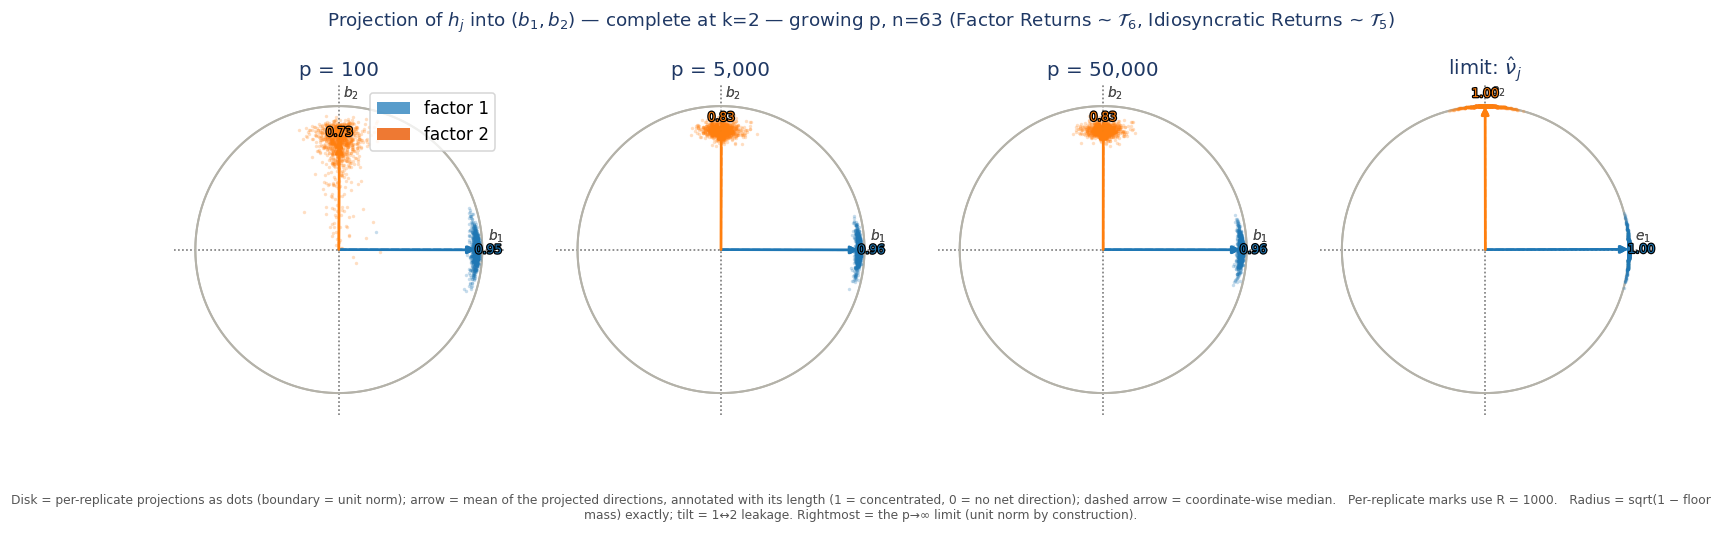

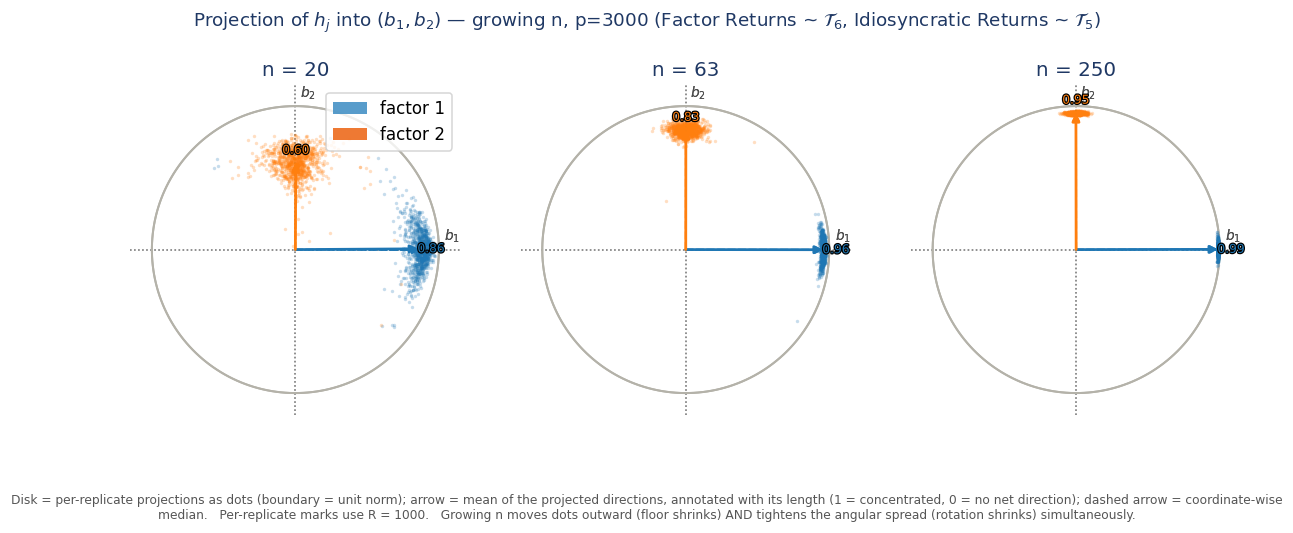

In [4]:
def proj_disk(at, coords="hf", prefix="b"):
    """Both factors' replicates as dots + mean arrows, plain projection."""
    return [DiskDensity(f"{coords}1", f"{coords}2", factor=f, at=at, mean_arrow=True,
                        median_arrow=True,
                        kde=False, scatter=10**6, label=f"factor {f}",
                        labels=(rf"${prefix}_1$", rf"${prefix}_2$"))
            for f in (1, 2)]


_P_STEPS = [100, 5000, 50000]
fig, _ = grid(
    df_p, "p", factors=[1] * (len(_P_STEPS) + 1),
    col_titles=[f"p = {v:,}" for v in _P_STEPS] + [r"limit: $\hat\nu_j$"],
    rows=[Row(cells=[proj_disk({"p": v}) for v in _P_STEPS]
                    + [proj_disk({"p": 50000}, coords="nud", prefix="e")],
              height=1.0)],
    sharey=False, figsize=(15.5, 4.9), formats=FIG_FORMATS,
    suptitle=rf"Projection of $h_j$ into $(b_1, b_2)$ — complete at k=2 — "
             rf"growing p, n=63 {_TAILS}",
    caption_extra="Radius = sqrt(1 − floor mass) exactly; tilt = 1↔2 leakage. "
                  "Rightmost = the p→∞ limit (unit norm by construction).",
    out_path=out("ex8_proj_growing_p"))
show(fig)

fig, _ = grid(
    df_n, "n", factors=[1, 2, 3],
    col_titles=[f"n = {v}" for v in (20, 63, 250)],
    rows=[Row(cells=[proj_disk({"n": v}) for v in (20, 63, 250)], height=1.0)],
    sharey=False, figsize=(11.8, 4.9), formats=FIG_FORMATS,
    suptitle=rf"Projection of $h_j$ into $(b_1, b_2)$ — growing n, p=3000 {_TAILS}",
    caption_extra="Growing n moves dots outward (floor shrinks) AND tightens the angular "
                  "spread (rotation shrinks) simultaneously.",
    out_path=out("ex8_proj_growing_n"))
show(fig)

## Step 5 — scalar view + numbers

The in-subspace rotation distribution with its $k\times k$ limit overlaid, per sweep, and
the 2×2 share matrices. With the near-degenerate pair removed, both factors should
identify cleanly at $n \geq 63$ — this is the benchmark the 3- and 6-factor notebooks
degrade from.

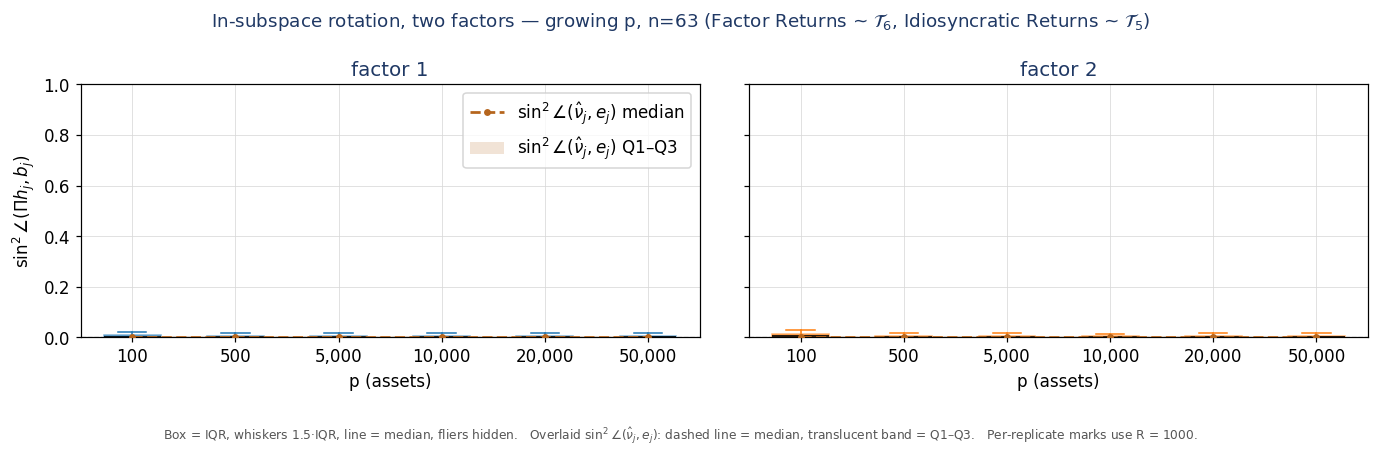

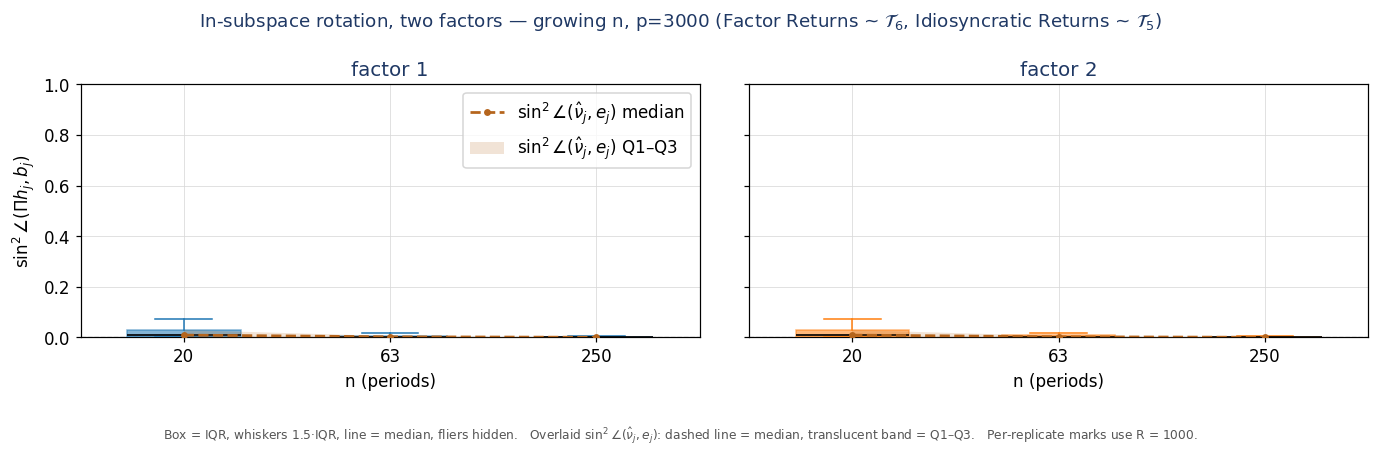

mean in-subspace mass share (%), n=20:


,h1,h2
b1,97.0,3.3
b2,3.0,96.7


mean in-subspace mass share (%), n=63:


,h1,h2
b1,99.4,0.6
b2,0.6,99.4


mean in-subspace mass share (%), n=250:


,h1,h2
b1,99.9,0.1
b2,0.1,99.9


∠(b_j, h_j) in degrees (median / p95), growing p at n=63:


median   p95
p     j              
100   1    17.1  22.7
      2    40.1  65.0
500   1    16.7  20.9
      2    34.6  41.9
5000  1    16.6  20.7
      2    33.7  38.5
10000 1    16.6  20.7
      2    33.5  38.5
20000 1    16.6  20.8
      2    33.5  38.4
50000 1    16.7  20.8
      2    33.5  38.5

In [5]:
for df, key, lab, stem in ((df_p, "p", "growing p, n=63", "ex8_insub_dist_p"),
                           (df_n, "n", "growing n, p=3000", "ex8_insub_dist_n")):
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True,
                  suptitle=f"In-subspace rotation, two factors — {lab} {_TAILS}",
                  out_path=out(stem))
    show(fig)


def share_matrix(df, at):
    s = df
    for c, v in at.items():
        s = s[s[c] == v]
    C2 = s[HB].to_numpy() ** 2
    C2 = C2 / C2.sum(axis=1, keepdims=True)
    return pd.DataFrame({f"h{j}": 100 * C2[s["j"].to_numpy() == j].mean(axis=0)
                         for j in range(1, K + 1)},
                        index=[f"b{i}" for i in range(1, K + 1)]).round(1)


for v in (20, 63, 250):
    print(f"mean in-subspace mass share (%), n={v}:")
    display(share_matrix(df_n, {"n": v}))

print("∠(b_j, h_j) in degrees (median / p95), growing p at n=63:")
_a = df_p.assign(ang=np.degrees(np.arccos(
    np.abs(df_p[HB].to_numpy()[np.arange(len(df_p)), df_p["j"].to_numpy() - 1]))))
display(_a.groupby(["p", "j"])["ang"]
          .agg(median="median", p95=lambda s: s.quantile(0.95)).round(1))

## Step 6 — coordinate marginals: one boxplot per inner product

Each panel is one inner product $\langle h_i, b_j\rangle$ — the cosine of the angle
between that estimated factor and that population direction — as a per-replicate
distribution across the sweep. Pairs are sign-folded (each replicate's pair flipped
together so the own-axis coordinate is positive); the dashed zero line is the reference
for the cross terms.

**What to look for:** the **diagonal** panels ($\langle h_1, b_1\rangle$,
$\langle h_2, b_2\rangle$) sit *below 1* — the attenuation $\cos\angle \approx$ 0.96 /
0.84, i.e. the persistent per-replicate angles (~17° / ~33°) that fixed $n$ cannot
remove. The **off-diagonal** panels are centered on 0 with shrinking spread — the errors
distribute evenly around the truth, which is why the mean arrows in Step 4 are parallel
to the axes.

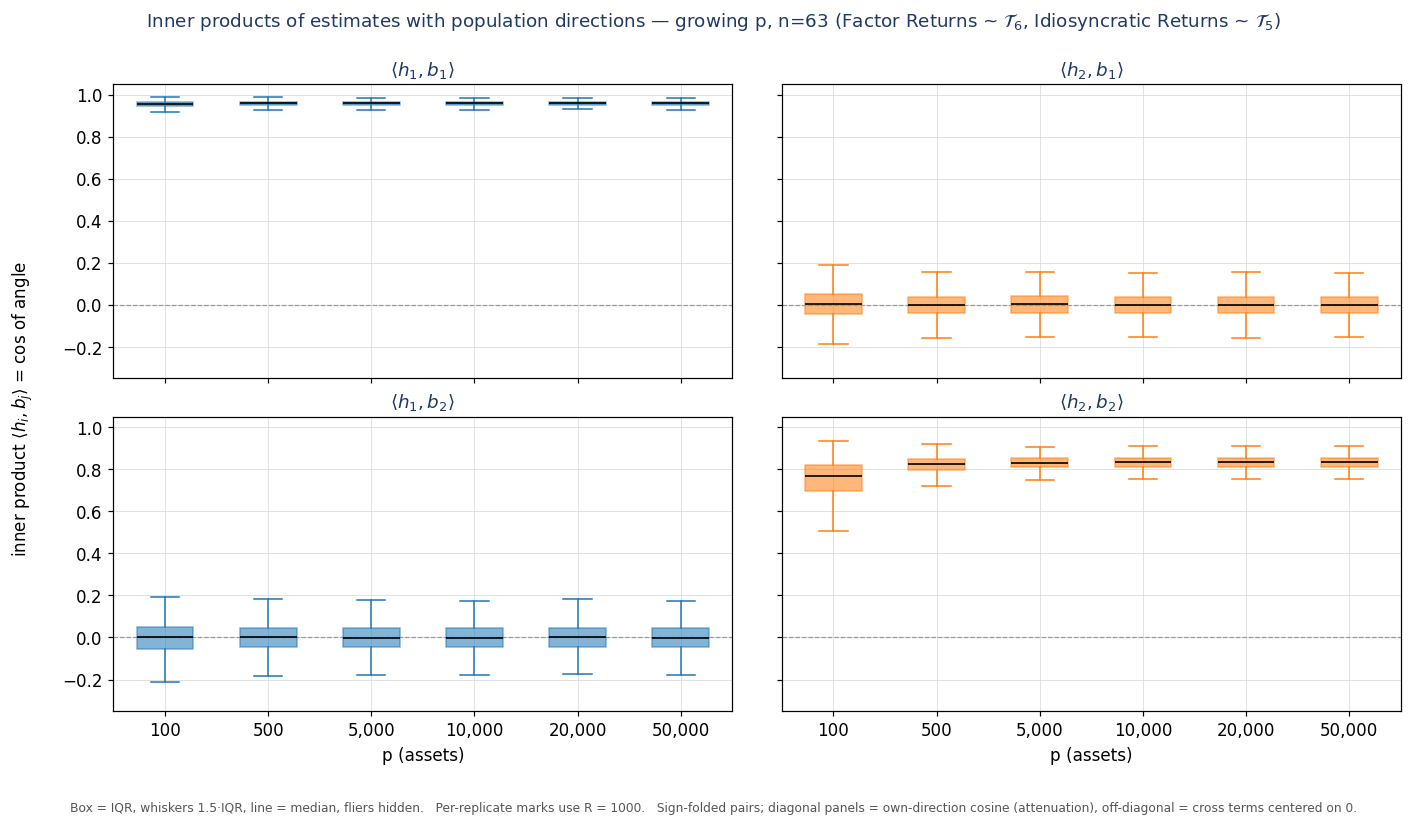

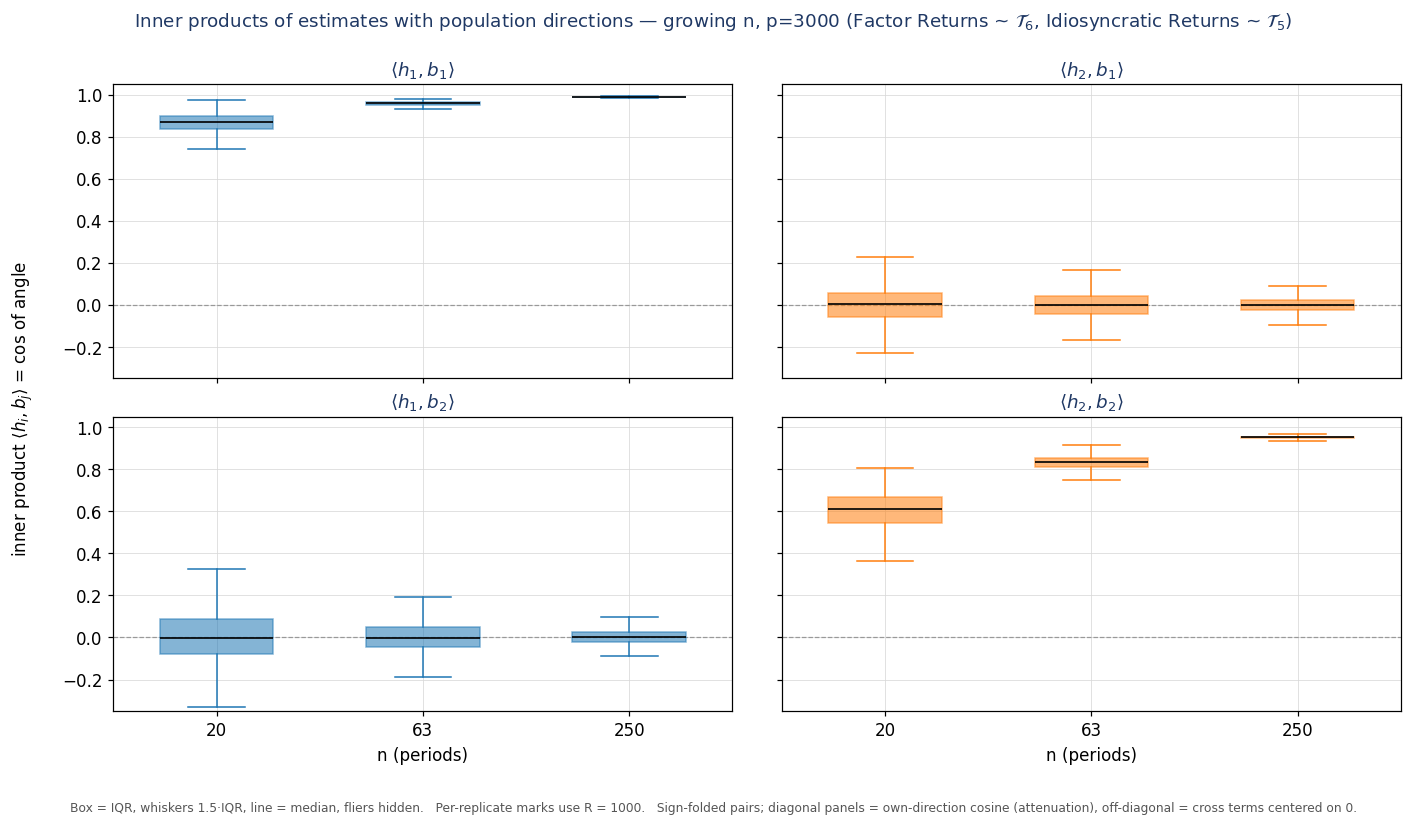

In [6]:
from fl_plot import save as fl_save

for df, key, lab, stem in ((df_p, "p", "growing p, n=63", "ex8_coord_box_p"),
                           (df_n, "n", "growing n, p=3000", "ex8_coord_box_n")):
    fig, axes = grid(df, key,
                     rows=[Row(BoxDist("hf1"), ylabel="", ylim=(-0.35, 1.05), height=1.0),
                           Row(BoxDist("hf2"), ylabel="", ylim=(-0.35, 1.05), height=1.0)],
                     sharey=True,
                     suptitle=f"Inner products of estimates with population directions — {lab} {_TAILS}",
                     caption_extra="Sign-folded pairs; diagonal panels = own-direction "
                                   "cosine (attenuation), off-diagonal = cross terms "
                                   "centered on 0.")
    # per-panel labels: rows are b_1, b_2; columns are h_1, h_2
    for ri, bi in enumerate((1, 2)):
        for ci, hi in enumerate((1, 2)):
            axes[ri, ci].set_title(rf"$\langle h_{hi}, b_{bi}\rangle$",
                                   color=THEME.navy, fontsize=12)
    fig.supylabel(r"inner product $\langle h_i, b_j\rangle$ = cos of angle", fontsize=11)
    _path = out(stem)
    if _path is not None:
        fl_save(fig, _path, formats=FIG_FORMATS)
    show(fig)